# 2. Análisis de Conglomerados (Clúster)

El análisis de conglomerados (**clustering**) es una técnica de aprendizaje no supervisado que busca agrupar
observaciones de manera que las que pertenecen al mismo grupo sean **muy similares entre sí**
y **muy diferentes de las de otros grupos**.

A diferencia de la clasificación supervisada, no conocemos las etiquetas de antemano:
son los propios datos los que revelan la estructura.

## Objetivos
- Comprender la lógica del clustering y cuándo aplicarlo.
- Implementar k-means y clustering jerárquico desde cero con Python.
- Evaluar la calidad del agrupamiento con índices formales.
- Interpretar los resultados y comunicarlos de forma práctica.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

## 1. Datos de trabajo

Generamos un conjunto de clientes ficticios con tres variables:

- **ingreso_mensual**: ingresos en miles de pesos.
- **gasto_mensual**: gasto promedio mensual en miles de pesos.
- **edad**: edad del cliente.

Existe una estructura latente de cuatro perfiles, que el clustering deberá redescubrir.

In [2]:
# Cuatro centros de grupos bien separados
centros = [
    [30, 25, 22],   # jóvenes, ingreso/gasto bajos
    [70, 60, 35],   # adultos, ingreso/gasto altos
    [80, 20, 50],   # maduros, ingreso alto / gasto bajo
    [40, 55, 28],   # jóvenes adultos, gasto alto relativo al ingreso
]

n_por_grupo = 80
bloques = []
for i, c in enumerate(centros):
    bloque = np.random.multivariate_normal(
        mean=c,
        cov=np.diag([25, 20, 16]),
        size=n_por_grupo
    )
    bloques.append(bloque)

X_raw = np.vstack(bloques)
etiquetas_reales = np.repeat([0, 1, 2, 3], n_por_grupo)

df = pd.DataFrame(X_raw, columns=['ingreso_mensual', 'gasto_mensual', 'edad'])
df['grupo_real'] = etiquetas_reales

print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (320, 4)


,ingreso_mensual,gasto_mensual,edad,grupo_real
0,32.483571,24.381663,24.590754,0
1,37.615149,23.952834,21.063452,0
2,37.896064,28.432072,20.122102,0
3,32.712800,22.927533,20.137081,0
4,31.209811,16.443551,15.100329,0


## 2. Preprocesamiento: estandarización

La mayoría de los algoritmos de clustering usan distancias.  
Si las variables tienen escalas diferentes, las de mayor magnitud dominarán las distancias y el resultado será sesgado.

La solución estándar es transformar cada variable $x_j$ a escala $z$:

$$z_j = \frac{x_j - \bar{x}_j}{s_j}$$

donde $\bar{x}_j$ y $s_j$ son la media y desviación estándar de la variable $j$.
Tras esta transformación todas las variables tienen media 0 y varianza 1.

In [3]:
features = ['ingreso_mensual', 'gasto_mensual', 'edad']
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

pd.DataFrame(X, columns=features).describe().round(3)

,ingreso_mensual,gasto_mensual,edad
count,320.000,320.000,320.000
mean,0.000,0.000,-0.000
std,1.002,1.002,1.002
min,-1.565,-1.709,-2.028
25%,-0.951,-0.965,-0.793
50%,0.017,0.037,-0.124
75%,0.975,0.951,0.710
max,1.788,1.829,2.323


## 3. K-Means

### 3.1 Fundamentos del algoritmo

K-means divide $n$ observaciones en $K$ grupos minimizando la **inercia total** (suma de cuadrados intra-cluster):

$$W(K) = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

donde $\boldsymbol{\mu}_k$ es el **centroide** (media) del grupo $k$.

**Algoritmo iterativo:**
1. Inicializar $K$ centroides (aleatoriamente o con k-means++).
2. **Asignación:** cada observación va al centroide más cercano.
3. **Actualización:** recalcular los centroides como la media de las observaciones asignadas.
4. Repetir 2–3 hasta convergencia.

**Ventajas:** rápido, escalable, fácil de interpretar.  
**Limitaciones:** sensible a valores atípicos, asume grupos esféricos, requiere fijar $K$ de antemano.

In [4]:
# Ajustamos k-means con K=4 (el verdadero número de grupos)
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X)

print('Distribución de observaciones por cluster:')
print(df['cluster_kmeans'].value_counts().sort_index())
print(f'\nInercia total: {kmeans.inertia_:.2f}')

Distribución de observaciones por cluster:
cluster_kmeans
0    80
1    80
2    80
3    80
Name: count, dtype: int64

Inercia total: 75.71


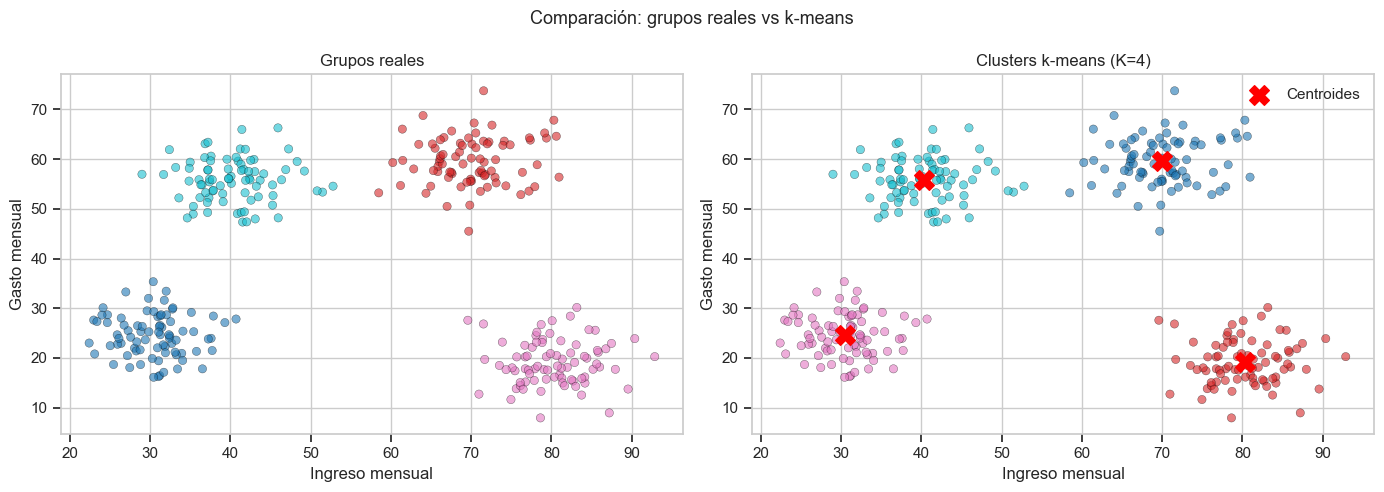

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo in zip(
    axes,
    ['grupo_real', 'cluster_kmeans'],
    ['Grupos reales', 'Clusters k-means (K=4)']
):
    scatter = ax.scatter(
        df['ingreso_mensual'], df['gasto_mensual'],
        c=df[col], cmap='tab10', alpha=0.6, edgecolors='k', linewidths=0.3
    )
    ax.set_xlabel('Ingreso mensual')
    ax.set_ylabel('Gasto mensual')
    ax.set_title(titulo)

# Marcar centroides en el gráfico de k-means
centroides_orig = scaler.inverse_transform(kmeans.cluster_centers_)
axes[1].scatter(
    centroides_orig[:, 0], centroides_orig[:, 1],
    marker='X', s=200, c='red', zorder=5, label='Centroides'
)
axes[1].legend()

plt.suptitle('Comparación: grupos reales vs k-means', fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 Método del codo para elegir K

No siempre conocemos el número de grupos. El **método del codo** traza la inercia $W(K)$
para distintos valores de $K$: a medida que $K$ crece, $W$ disminuye, pero cada grupo adicional
aporta cada vez menos. El punto donde la curva "dobla" (el codo) sugiere el número óptimo.

> El método del codo es heurístico; debe complementarse con índices formales.

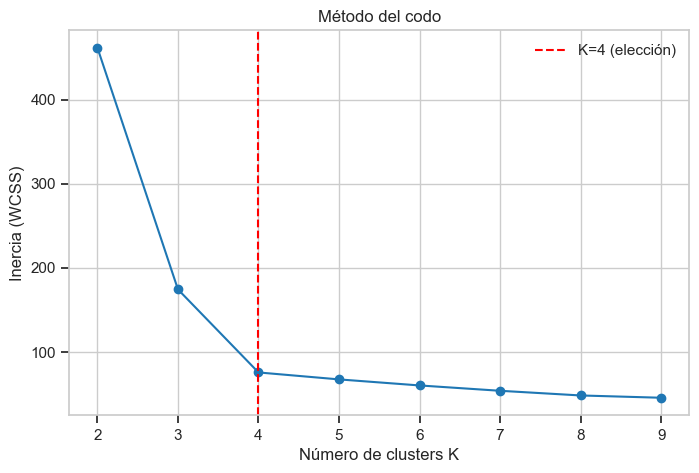

In [6]:
K_range = range(2, 10)
inercias = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    km.fit(X)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inercias, marker='o')
plt.axvline(4, color='red', linestyle='--', label='K=4 (elección)')
plt.xlabel('Número de clusters K')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del codo')
plt.legend()
plt.xticks(K_range)
plt.show()

## 4. Clustering Jerárquico

### 4.1 Fundamentos

El clustering jerárquico construye una **jerarquía anidada** de grupos sin fijar $K$ de antemano.
El enfoque más común es el **aglomerativo** (*bottom-up*):

1. Cada observación comienza como su propio grupo.
2. Se fusionan los dos grupos más similares.
3. Se repite hasta que todos forman un único gran grupo.

La similitud entre grupos depende del **método de enlace** (*linkage*):

| Método | Distancia entre grupos $A$ y $B$ |
|--------|----------------------------------|
| Single | $\min_{i \in A,\, j \in B} d(i,j)$ |
| Complete | $\max_{i \in A,\, j \in B} d(i,j)$ |
| Average | $\frac{1}{|A||B|}\sum_{i \in A}\sum_{j \in B} d(i,j)$ |
| Ward | Minimiza el incremento de varianza intra-cluster |

El resultado se visualiza en un **dendrograma**, que permite elegir $K$ cortando el árbol
a una determinada altura.

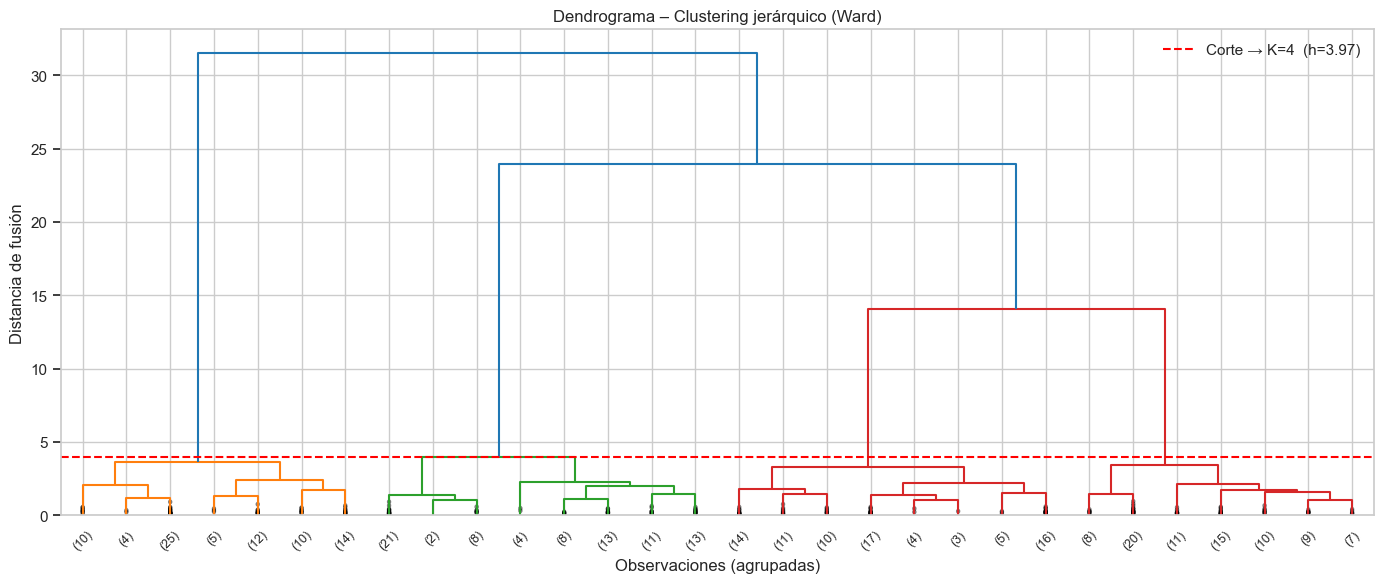

In [7]:
# Construimos la matriz de enlace con el método Ward
Z = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',   # mostrar solo las últimas p fusiones
    p=30,
    show_contracted=True,
    leaf_font_size=9
)
ax.set_title('Dendrograma – Clustering jerárquico (Ward)')
ax.set_xlabel('Observaciones (agrupadas)')
ax.set_ylabel('Distancia de fusión')

# Línea de corte sugerida para K=4
umbral = Z[-4, 2]  # altura antes de la 4.ª fusión desde el tope
ax.axhline(umbral, color='red', linestyle='--', label=f'Corte → K=4  (h={umbral:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Cortar el árbol para obtener K=4 grupos
df['cluster_hier'] = fcluster(Z, t=4, criterion='maxclust')

print('Distribución de observaciones por cluster jerárquico:')
print(df['cluster_hier'].value_counts().sort_index())

Distribución de observaciones por cluster jerárquico:
cluster_hier
1    80
2    80
3    80
4    80
Name: count, dtype: int64


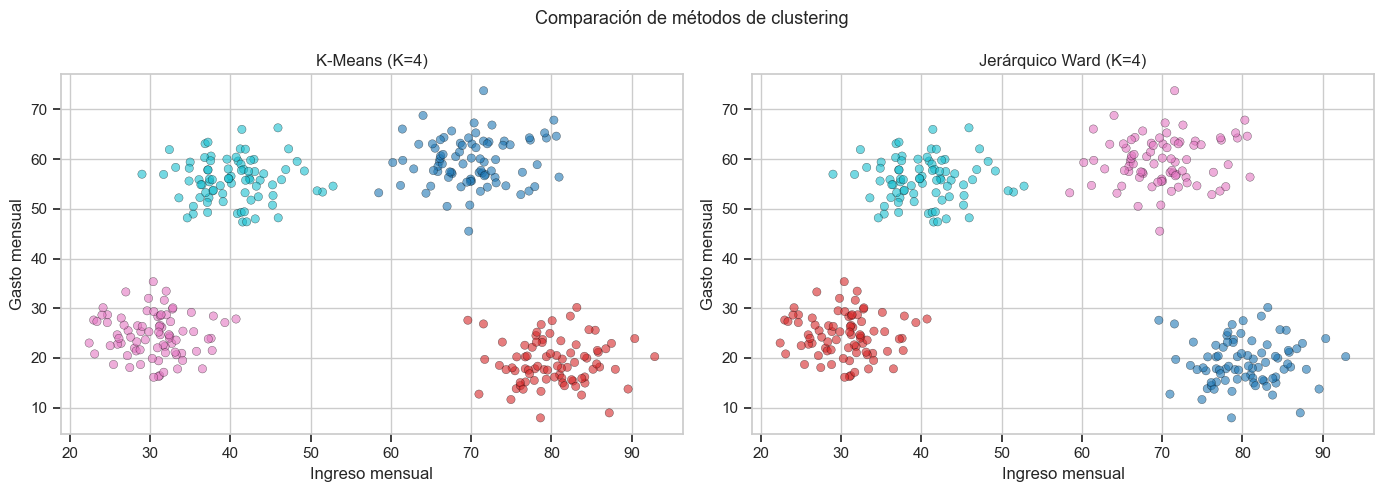

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo in zip(
    axes,
    ['cluster_kmeans', 'cluster_hier'],
    ['K-Means (K=4)', 'Jerárquico Ward (K=4)']
):
    ax.scatter(
        df['ingreso_mensual'], df['gasto_mensual'],
        c=df[col], cmap='tab10', alpha=0.6, edgecolors='k', linewidths=0.3
    )
    ax.set_xlabel('Ingreso mensual')
    ax.set_ylabel('Gasto mensual')
    ax.set_title(titulo)

plt.suptitle('Comparación de métodos de clustering', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Evaluación de la calidad del agrupamiento

Dado que el clustering es **no supervisado**, necesitamos métricas internas
(calculadas solo con los datos, sin etiquetas verdaderas) para juzgar la calidad.

### 5.1 Coeficiente de silueta

Para cada observación $i$, se calcula:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

donde:
- $a(i)$ = distancia media de $i$ a los demás puntos de **su propio** cluster.
- $b(i)$ = distancia media mínima de $i$ a los puntos del cluster **vecino más cercano**.

$s(i) \in [-1, 1]$. Valores cercanos a **+1** indican que $i$ está bien asignado; cercanos a **0**, en
la frontera; negativos, posiblemente mal clasificado.

El **coeficiente global** $\bar{s}$ es el promedio sobre todas las observaciones.

### 5.2 Índice de Davies-Bouldin

$$DB = \frac{1}{K}\sum_{k=1}^{K}\max_{j \neq k}\left(\frac{\sigma_k + \sigma_j}{d(\boldsymbol{\mu}_k, \boldsymbol{\mu}_j)}\right)$$

donde $\sigma_k$ es la dispersión media del cluster $k$ y $d(\boldsymbol{\mu}_k, \boldsymbol{\mu}_j)$ la distancia entre centroides.
**Menor** es mejor.

### 5.3 Índice de Calinski-Harabasz

$$CH = \frac{SS_B / (K-1)}{SS_W / (n-K)}$$

donde $SS_B$ es la varianza entre clusters y $SS_W$ la varianza dentro. **Mayor** es mejor.

In [10]:
metodos = {
    'K-Means': df['cluster_kmeans'].values,
    'Jerárquico': df['cluster_hier'].values,
}

resultados = []
for nombre, etiquetas in metodos.items():
    resultados.append({
        'Método': nombre,
        'Silueta': silhouette_score(X, etiquetas),
        'Davies-Bouldin': davies_bouldin_score(X, etiquetas),
        'Calinski-Harabasz': calinski_harabasz_score(X, etiquetas),
    })

df_eval = pd.DataFrame(resultados).set_index('Método')
df_eval.round(4)

,Silueta,Davies-Bouldin,Calinski-Harabasz
Método,,,
K-Means,0.6618,0.4794,1230.3227
Jerárquico,0.6618,0.4794,1230.3227


### 5.4 Gráfico de silueta individual

El gráfico de silueta individual muestra el coeficiente $s(i)$ de cada observación,
ordenada por cluster. Permite detectar clusters débiles (con muchas siluetas negativas)
y evaluar si los grupos tienen tamaños razonablemente equilibrados.

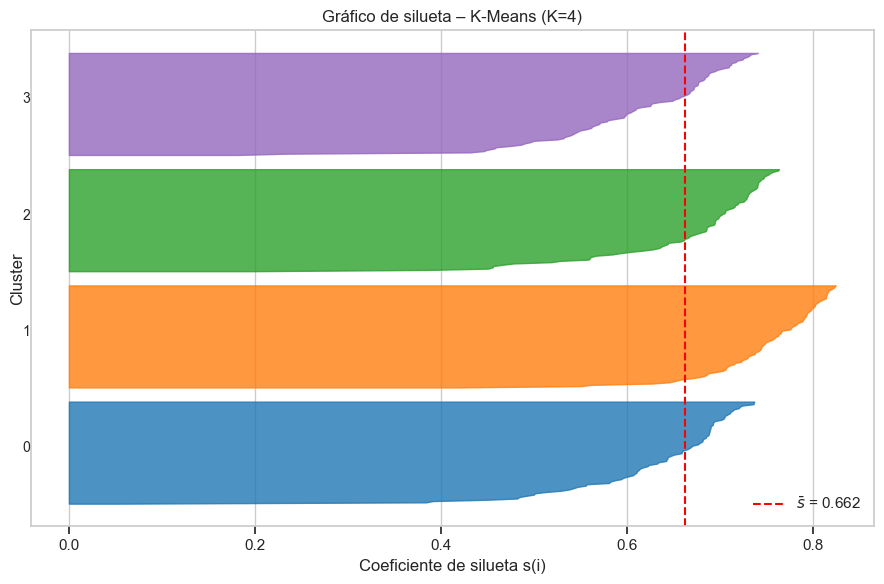

In [11]:
etiquetas_km = df['cluster_kmeans'].values
siluetas = silhouette_samples(X, etiquetas_km)
K = 4

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colores = cm.tab10(np.linspace(0, 0.4, K))

for k, color in zip(range(K), colores):
    vals = np.sort(siluetas[etiquetas_km == k])
    size_k = len(vals)
    y_upper = y_lower + size_k

    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, vals,
        facecolor=color, edgecolor=color, alpha=0.8
    )
    ax.text(-0.05, y_lower + size_k / 2, str(k), fontsize=10)
    y_lower = y_upper + 10

media_sil = silhouette_score(X, etiquetas_km)
ax.axvline(media_sil, color='red', linestyle='--', label=f'$\\bar{{s}}$ = {media_sil:.3f}')
ax.set_xlabel('Coeficiente de silueta s(i)')
ax.set_ylabel('Cluster')
ax.set_title('Gráfico de silueta – K-Means (K=4)')
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.5 Índices vs número de clusters K

Graficamos los tres índices para $K = 2, \ldots, 9$ para confirmar que $K=4$ es la mejor elección.

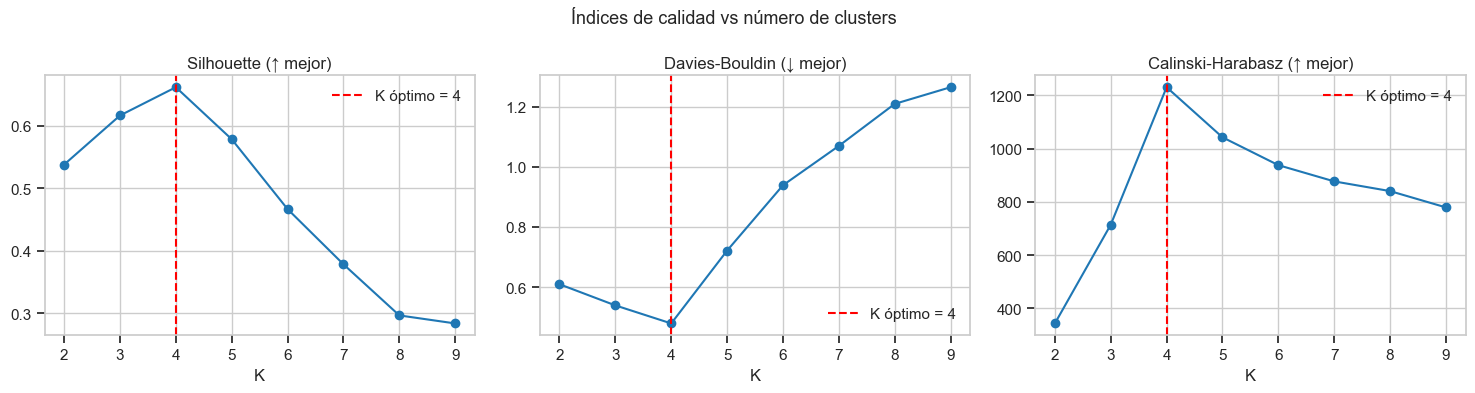

In [12]:
K_range = range(2, 10)
sil_vals, db_vals, ch_vals = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    etq = km.fit_predict(X)
    sil_vals.append(silhouette_score(X, etq))
    db_vals.append(davies_bouldin_score(X, etq))
    ch_vals.append(calinski_harabasz_score(X, etq))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, vals, titulo, mejor in zip(
    axes,
    [sil_vals, db_vals, ch_vals],
    ['Silhouette (↑ mejor)', 'Davies-Bouldin (↓ mejor)', 'Calinski-Harabasz (↑ mejor)'],
    ['max', 'min', 'max']
):
    ax.plot(K_range, vals, marker='o')
    k_optimo = list(K_range)[np.argmax(vals) if mejor == 'max' else np.argmin(vals)]
    ax.axvline(k_optimo, color='red', linestyle='--', label=f'K óptimo = {k_optimo}')
    ax.set_xlabel('K')
    ax.set_title(titulo)
    ax.set_xticks(K_range)
    ax.legend()

plt.suptitle('Índices de calidad vs número de clusters', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Interpretación y uso de los resultados

Una vez validada la solución de $K=4$ clusters, el paso final y más valioso es
**describir cada grupo** en términos de las variables originales para darle significado.

### 6.1 Perfil de cada cluster

In [13]:
perfil = (
    df.groupby('cluster_kmeans')[features]
    .agg(['mean', 'std', 'count'])
)
perfil.columns = [f'{v}_{stat}' for v, stat in perfil.columns]
perfil.round(2)

,ingreso_mensual_mean,ingreso_mensual_std,ingreso_mensual_count,gasto_mensual_mean,gasto_mensual_std,gasto_mensual_count,edad_mean,edad_std,edad_count
cluster_kmeans,,,,,,,,,
0,70.04,4.93,80,59.57,4.80,80,35.78,3.58,80
1,80.33,4.59,80,19.09,4.50,80,49.78,4.26,80
2,30.47,3.96,80,24.56,4.26,80,21.99,4.56,80
3,40.35,4.58,80,55.74,4.31,80,28.54,3.86,80


### 6.2 Distribución de variables por cluster

Los diagramas de caja permiten comparar visualmente la distribución de cada variable en los distintos grupos.

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_57727/3934589525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_57727/3934589525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_57727/3934589525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


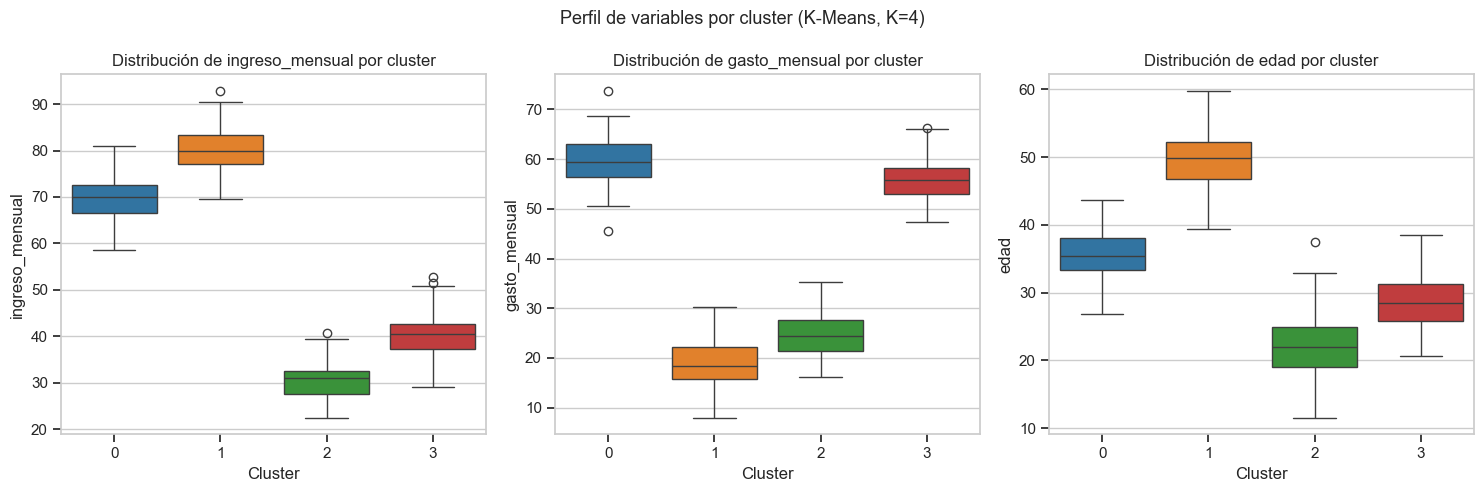

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, features):
    sns.boxplot(
        data=df, x='cluster_kmeans', y=var,
        palette='tab10', ax=ax
    )
    ax.set_title(f'Distribución de {var} por cluster')
    ax.set_xlabel('Cluster')

plt.suptitle('Perfil de variables por cluster (K-Means, K=4)', fontsize=13)
plt.tight_layout()
plt.show()

### 6.3 Mapa de calor de centroides estandarizados

Visualizar los centroides en escala $z$ es útil para comparar las características
relativas de cada cluster de un vistazo: valores positivos indican que el cluster
está *por encima* de la media global y negativos, *por debajo*.

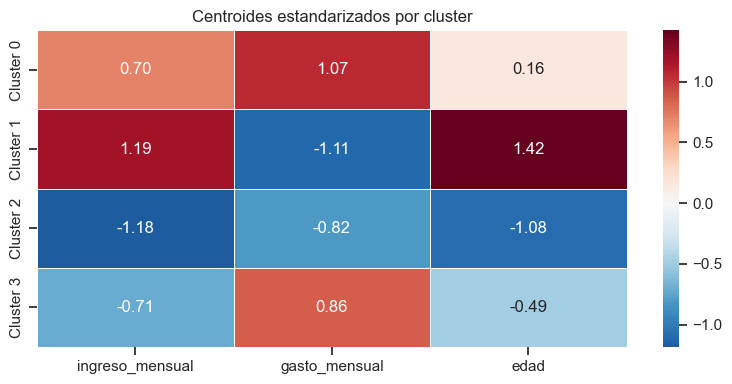

In [15]:
centroides_std = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features,
    index=[f'Cluster {k}' for k in range(K)]
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    centroides_std,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5
)
plt.title('Centroides estandarizados por cluster')
plt.tight_layout()
plt.show()

### 6.4 Etiquetado de los clusters

A partir del perfil cuantitativo, podemos asignar **nombres interpretables** a cada cluster.
Esto facilita la comunicación de resultados con equipos no técnicos.

El siguiente paso es inspeccionar los centroides en la escala original.

In [16]:
centroides_orig_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features,
    index=[f'Cluster {k}' for k in range(K)]
).round(1)

centroides_orig_df

,ingreso_mensual,gasto_mensual,edad
Cluster 0,70.0,59.6,35.8
Cluster 1,80.3,19.1,49.8
Cluster 2,30.5,24.6,22.0
Cluster 3,40.3,55.7,28.5


In [17]:
# Ejemplo de etiquetado manual basado en la inspección de centroides
# (los números de cluster pueden variar en cada ejecución)
medias_ingreso = centroides_orig_df['ingreso_mensual']
medias_gasto = centroides_orig_df['gasto_mensual']
medias_edad = centroides_orig_df['edad']

etiquetas_cluster = {}
for k in range(K):
    ing = medias_ingreso[f'Cluster {k}']
    gas = medias_gasto[f'Cluster {k}']
    eda = medias_edad[f'Cluster {k}']
    ratio = gas / ing

    if eda < 30:
        perfil_str = 'Jóvenes ahorradores'
    elif ing > 65 and gas > 55:
        perfil_str = 'Adultos alto poder adquisitivo'
    elif ing > 65 and gas < 35:
        perfil_str = 'Maduros conservadores'
    else:
        perfil_str = 'Jóvenes adultos gastadores'

    etiquetas_cluster[k] = perfil_str
    print(f'Cluster {k}: {perfil_str}  (ingreso={ing:.0f}, gasto={gas:.0f}, edad={eda:.0f})')

df['perfil'] = df['cluster_kmeans'].map(etiquetas_cluster)

Cluster 0: Adultos alto poder adquisitivo  (ingreso=70, gasto=60, edad=36)
Cluster 1: Maduros conservadores  (ingreso=80, gasto=19, edad=50)
Cluster 2: Jóvenes ahorradores  (ingreso=30, gasto=25, edad=22)
Cluster 3: Jóvenes ahorradores  (ingreso=40, gasto=56, edad=28)


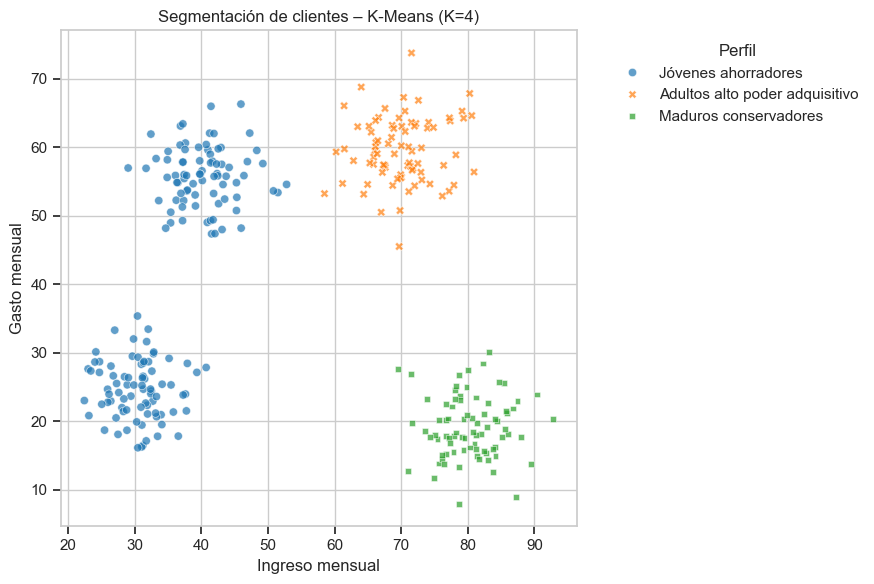

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x='ingreso_mensual', y='gasto_mensual',
    hue='perfil', style='perfil', alpha=0.7
)
plt.title('Segmentación de clientes – K-Means (K=4)')
plt.xlabel('Ingreso mensual')
plt.ylabel('Gasto mensual')
plt.legend(title='Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.5 Uso práctico de los resultados

Una vez identificados los segmentos, los resultados del clustering pueden aplicarse en:

| Dominio | Aplicación |
|---------|------------|
| Marketing | Campañas y mensajes diferenciados por perfil de cliente |
| Finanzas | Scoring y límite de crédito diferenciado por segmento |
| Salud pública | Grupos de riesgo para intervenciones focalizadas |
| Bioinformática | Agrupamiento de genes con expresión similar |
| Retroalimentación de modelos | Etiquetas generadas como insumo para clasificación supervisada |

**Pasos para comunicar resultados:**
1. Describir el perfil promedio de cada cluster (centroides en escala original).
2. Cuantificar el tamaño relativo de cada grupo.
3. Validar con índices de calidad (silueta, Davies-Bouldin, Calinski-Harabasz).
4. Asignar etiquetas comprensibles para el dominio de negocio.
5. Documentar el preprocesamiento para reproducir la segmentación con datos nuevos.

## 7. Caso práctico integrador: clustering jerárquico con distintos enlaces

Comparamos los dendrogramas obtenidos con cuatro métodos de enlace para ilustrar
cómo la elección afecta la estructura latente detectada.

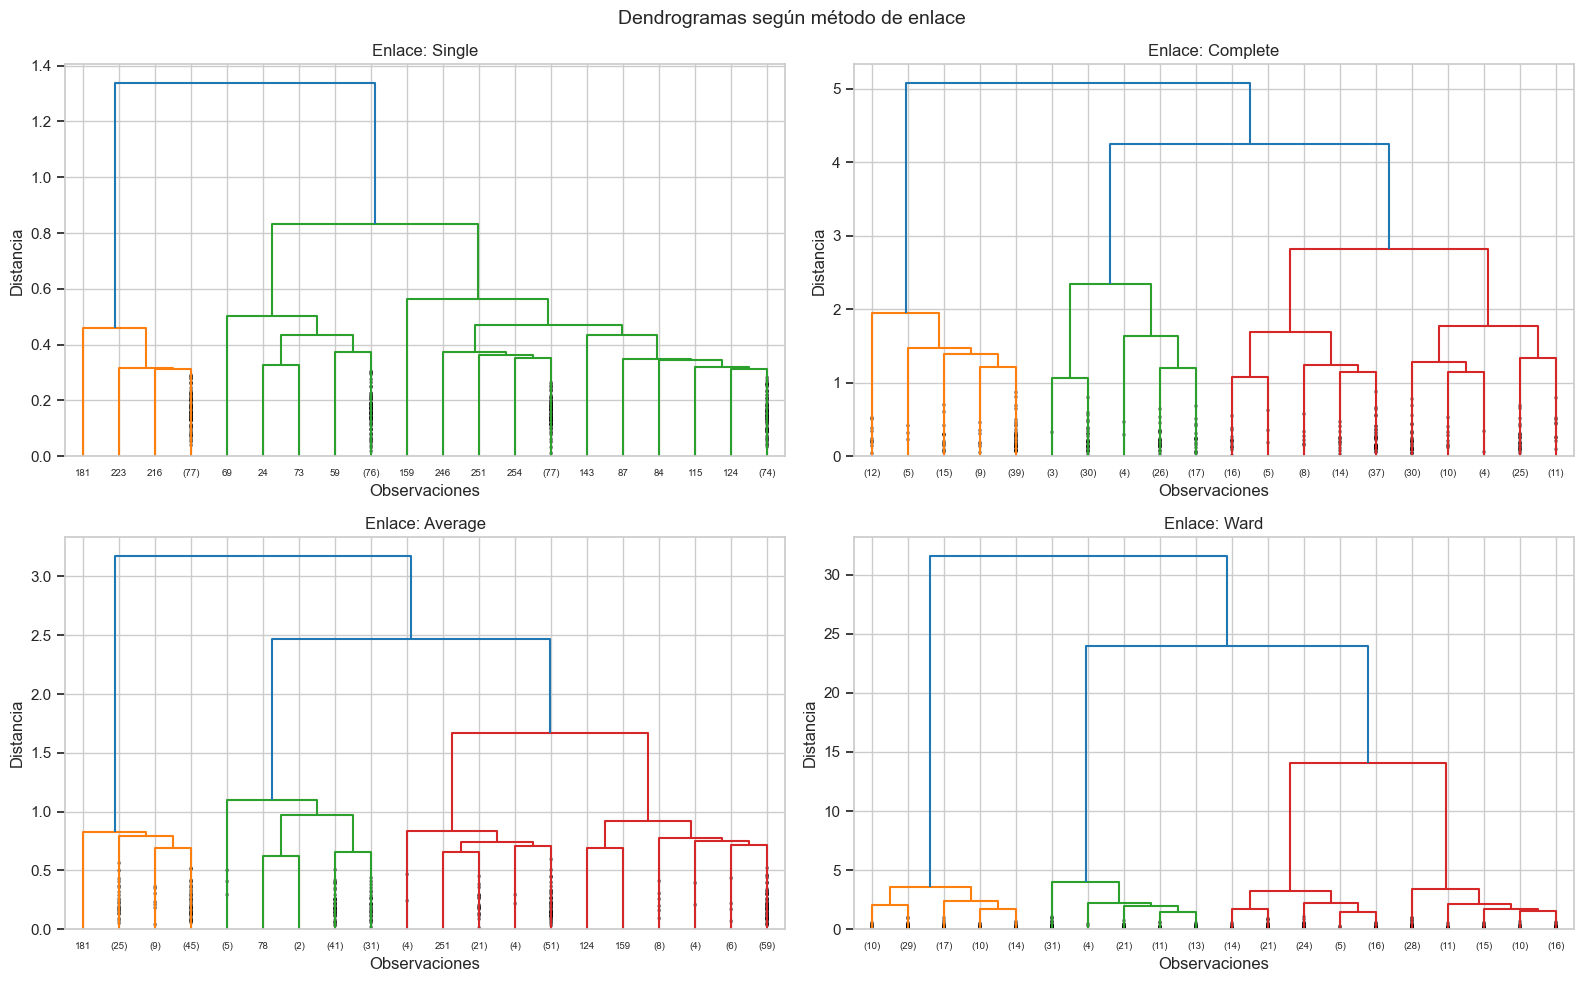

In [19]:
metodos_linkage = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metodo in zip(axes.flat, metodos_linkage):
    Z_m = linkage(X, method=metodo)
    dendrogram(
        Z_m, ax=ax,
        truncate_mode='lastp', p=20,
        show_contracted=True,
        leaf_font_size=7
    )
    ax.set_title(f'Enlace: {metodo.capitalize()}')
    ax.set_xlabel('Observaciones')
    ax.set_ylabel('Distancia')

plt.suptitle('Dendrogramas según método de enlace', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretación de los métodos de enlace:**

- **Single**: sensible a la forma de cadena (*chaining effect*); une grupos si al menos un par de puntos es cercano. Útil para formas no convexas.
- **Complete**: une grupos solo cuando **todos** sus puntos son cercanos. Tiende a crear clusters compactos pero puede romper grupos grandes.
- **Average**: equilibrio entre single y complete. Robusto y ampliamente usado.
- **Ward**: minimiza la varianza interna; produce clusters de tamaños similares y es equivalente a k-means en espacio euclidiano. Recomendado para datos cuantitativos estandarizados.

## 8. Resumen comparativo

| Criterio | K-Means | Jerárquico (Ward) |
|----------|---------|-------------------|
| Requiere fijar K | Sí | No (se decide al cortar) |
| Complejidad | $O(nKI)$ | $O(n^2 \log n)$ |
| Sensible a valores atípicos | Sí | Menos (Ward) |
| Forma de clusters | Esféricas | Flexible |
| Reproducible | Con semilla fija | Sí |
| Escalabilidad | Alta | Media |
| Dendrograma | No | Sí |

**Regla práctica:** para exploración inicial o grandes volúmenes de datos, inicia con k-means.
Para tamaños moderados y cuando la jerarquía importa, usa enlace Ward.
Siempre valida con índices de silueta y Davis-Bouldin antes de concluir.

## 9. Ejercicios propuestos

1. Repite el análisis con $K = 3$ y $K = 5$. ¿Cómo cambian los índices de calidad? ¿Cuál solución prefieres y por qué?

2. Carga el dataset `Iris` de `sklearn.datasets` y aplica k-means. Compara los clusters obtenidos con las especies reales usando la métrica de silueta.

3. ¿Qué ocurre si **no** estandarizas las variables antes de clustering? Realiza el análisis sin escalado y compara los resultados.

4. Implementa el método del codo y el análisis de silueta en un mismo gráfico y discute si coinciden en la elección de $K$.

5. Aplica clustering jerárquico con enlace `average` y compara el dendrograma con el de `ward`. ¿Cuál detecta mejor los 4 grupos reales?